<a href="https://colab.research.google.com/github/Jayapriya49/Applied-AI/blob/main/ex10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving Screenshot 2026-03-30 151312.png to Screenshot 2026-03-30 151312.png


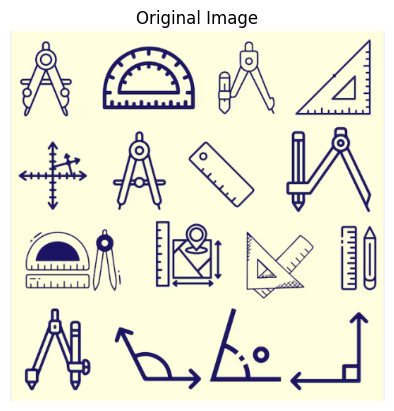

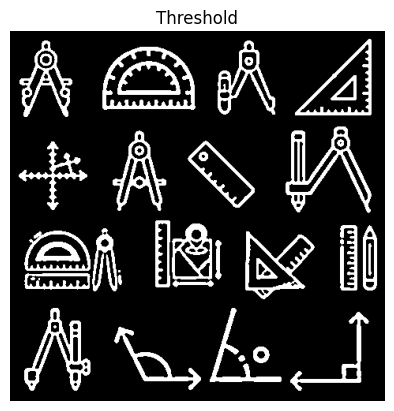

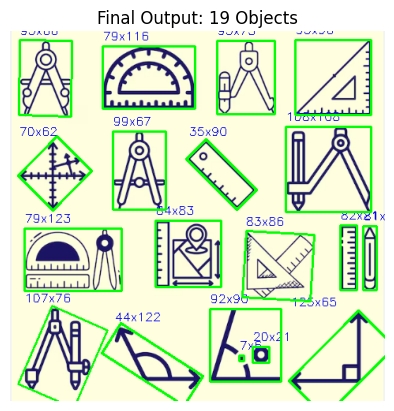

Total objects detected: 19
Latency: 0.189 seconds


In [1]:
# Install
!pip install imutils -q

# Imports
import cv2
import numpy as np
import imutils
import time
from matplotlib import pyplot as plt
from google.colab import files

# ---------- Helper Functions ----------

def preprocess(img):
    gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray_img, (7, 7), 0)

    thresh_img = cv2.adaptiveThreshold(
        blurred, 255,
        cv2.ADAPTIVE_THRESH_MEAN_C,
        cv2.THRESH_BINARY_INV,
        11, 3
    )

    edges = cv2.Canny(blurred, 40, 140)

    kernel = np.ones((3, 3), np.uint8)
    edges = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel, iterations=2)

    return thresh_img, edges


def detect_objects(edge_img, draw_img):
    contours = cv2.findContours(edge_img.copy(),
                                cv2.RETR_EXTERNAL,
                                cv2.CHAIN_APPROX_SIMPLE)
    contours = imutils.grab_contours(contours)

    count = 0

    for cnt in contours:
        if cv2.contourArea(cnt) < 20:
            continue

        count += 1

        rect = cv2.minAreaRect(cnt)
        box = cv2.boxPoints(rect)
        box = np.array(box, dtype="int")

        cv2.drawContours(draw_img, [box], -1, (0, 255, 0), 2)

        width, height = rect[1]
        x, y, w, h = cv2.boundingRect(cnt)

        label = "{}x{}".format(int(width), int(height))

        cv2.putText(draw_img,
                    label,
                    (x, y - 8),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.5,
                    (255, 0, 0),
                    1)

    return draw_img, count


# ---------- Main Flow ----------

# Upload
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# Load
img = cv2.imread(img_path)

# Show original
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")
plt.show()

# Start timing
start = time.time()

# Preprocess
threshold_img, edge_img = preprocess(img)

# Show ONLY threshold (edges removed)
plt.imshow(threshold_img, cmap='gray')
plt.title("Threshold")
plt.axis("off")
plt.show()

# Detect objects
output_img, total = detect_objects(edge_img, img)

# End timing
end = time.time()
latency = end - start

# Final output
plt.imshow(cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB))
plt.title(f"Final Output: {total} Objects")
plt.axis("off")
plt.show()

# Console output
print("Total objects detected:", total)
print("Latency: {:.3f} seconds".format(latency))